# Realized Volatility Bayesian Prediction - clean notebook

## Introduction

### Volatility and Its Role in Financial Markets

Volatility is one of the most important quantities in financial markets. In simple terms, it measures how strongly asset prices fluctuate over time. For investors, portfolio managers, and risk managers, volatility is not only a statistical concept but also a practical measure of uncertainty and exposure. Periods of high volatility are often associated with market stress, liquidity problems, wider risk limits, and larger potential losses. For this reason, forecasting volatility is important for portfolio allocation, option pricing, risk monitoring, among other applications.

Intuitively, volatility can be understood as the degree of instability. A simple analogy is daily weather. If the weather is stable, a child leaving for school in the morning can dress with confidence because the conditions are unlikely to change dramatically during the day. On the other hand, if the weather is highly volatile, the same child may need a winter hat and gloves in the morning, but by noon, when the temperature suddenly rises, he will need a Hawaiian shirt and flip-flops. The problem is not only whether the temperature is high or low, but how uncertain and changeable it is. Financial volatility plays a similar role: it measures how strongly and unpredictably the price of an asset changes over time.

### Why Volatility Forecasting Is Difficult

At the same time, volatility is difficult to predict. Markets often move between calmer and more turbulent regimes, and once volatility increases, it may remain elevated for some time. However, the timing and size of these changes are hard to anticipate, especially when markets react to macroeconomic news, financial crises, policy announcements, or unexpected shocks. This creates a difficult modeling problem: standard linear models may capture the smoother part of volatility dynamics, but they often fail to anticipate sudden spikes. In addition, realized volatility is highly right-skewed and heavy-tailed, so modeling it directly on the raw scale can lead to unstable forecasts and poor out-of-sample performance.

### Modeling Approach

This project studies realized variance forecasting for the S&P 500 using HAR-type models. The HAR framework is a natural starting point because it represents volatility persistence across different time horizons: daily, weekly, and monthly. We first estimate classical HAR models on raw realized variance using OLS and Ridge regression. We then test a simple jump-regime extension designed to capture periods where recent short-term volatility is high relative to longer-term volatility. These models provide useful baselines, but they also show the limitations of raw-scale volatility prediction.

To address these limitations, we move to a log-volatility specification. Taking logarithms reduces the impact of extreme spikes, makes the target more stable, and ensures that predictions mapped back to the original scale remain positive. We then estimate Bayesian HAR models with both Normal and Student-t likelihoods. The Bayesian approach is useful because it does not only produce a single point forecast. Instead, it produces a posterior predictive distribution, which describes a range of possible future volatility outcomes.

### Warning Framework Motivation

This leads to the main idea of the project: a high-volatility warning framework. In risk management, the goal is often not to predict the exact future value of volatility. A more useful question is whether future volatility is likely to become high enough to expose the portfolio to significant risk. We therefore define high-volatility events as observations where future five-day realized variance exceeds its 80th percentile. We then compare warning rules based on classical mean forecasts, Bayesian posterior predictive means, and upper predictive bounds of the Bayesian Student-t model.

The warning framework is interesting because it makes the trade-off explicit. Mean-based forecasts are conservative and issue few warnings, but they miss many high-volatility events. Upper predictive bounds incorporate uncertainty and therefore issue more warnings, increasing recall at the cost of lower precision. This is a natural dilemma in risk management: missing a volatility spike may be more costly than sending an additional false alarm. The project therefore evaluates not only forecasting accuracy, but also the practical usefulness of uncertainty-aware volatility warnings.

### Notebook Flow

The flow is intentionally notebook-like. We want to take the reader through the same thinking process as the analysis developed:

1. download market prices,
2. construct realized variance,
3. fit a basic HAR model,
4. try a jump-regime HAR extension,
5. switch to a log-HAR specification,
6. compare naive benchmarks,
7. fit Bayesian HAR models with Normal and Student-t likelihoods,
8. use posterior predictive intervals and upper predictive bounds for high-volatility warning signals.


## 0. Imports


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import pymc as pm
import arviz as az

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)


g++ not available, if using conda: `conda install gxx`


In [2]:
START = "2010-01-01"
END = "2023-01-01"
TRAIN_FRACTION = 0.80
EPS = 1e-12

# For final results use values like 1000/500/2.
# For quick testing set e.g. DRAWS=100, TUNE=100, CHAINS=1.
DRAWS = 1000
TUNE = 500
CHAINS = 3
TARGET_ACCEPT = 0.90
RANDOM_SEED = 42


## 1. Download market data

This is the same starting point as in `prep_data`: download S&P 500, NASDAQ and
VIX from Yahoo Finance.


In [3]:

from pathlib import Path

data_path = Path("data/prices_2010_2023.csv")
data_path.parent.mkdir(exist_ok=True)

if data_path.exists():
    close = pd.read_csv(data_path, index_col=0, parse_dates=True)
else:
    tickers = ["^GSPC", "^IXIC", "^VIX"]

    data = yf.download(
        tickers,
        start=START,
        end=END,
        auto_adjust=True,
        progress=False,
        threads=False,
    )

    close = data["Close"].rename(columns={
        "^GSPC": "SP500",
        "^IXIC": "NASDAQ",
        "^VIX": "VIX",
    })

    close.to_csv(data_path)

close.head()

,SP500,NASDAQ,VIX
Date,,,
2010-01-04,1132.989990,2308.419922,20.040001
2010-01-05,1136.520020,2308.709961,19.350000
2010-01-06,1137.140015,2301.090088,19.160000
2010-01-07,1141.689941,2300.050049,19.059999
2010-01-08,1144.979980,2317.169922,18.129999


In [4]:
close = close.rename(columns={
    "^GSPC": "SP500",
    "^IXIC": "NASDAQ",
    "^VIX": "VIX",
})

close.head()


,SP500,NASDAQ,VIX
Date,,,
2010-01-04,1132.989990,2308.419922,20.040001
2010-01-05,1136.520020,2308.709961,19.350000
2010-01-06,1137.140015,2301.090088,19.160000
2010-01-07,1141.689941,2300.050049,19.059999
2010-01-08,1144.979980,2317.169922,18.129999


## 2. First pass: HAR model on S&P 500 realized variance

We start exactly like in `prep_data`: take S&P 500, compute daily log returns,
realized variance, lagged HAR features and 5-day forward realized variance.

Daily realized variance is defined as

$$
RV_t = \left(\log\frac{S_t}{S_{t-1}}\right)^2.
$$

The HAR model uses volatility averages over different horizons: one day, one
week, and one month. In the first specification we model the future 5-day mean
realized variance directly:

$$
RV^{mean}_t =
\beta_0
+ \beta_1 RV^{-1}_t
+ \beta_2 RV^{-5}_t
+ \beta_3 RV^{-22}_t
+ \epsilon_t,
$$

where

$$
RV^{-h}_t = \frac{1}{h}\sum_{i=1}^{h} RV_{t-i}.
$$

The prediction target is

$$
RV^{mean}_t = \frac{1}{5}\sum_{i=1}^{5} RV_{t+i}.
$$

This first model is intentionally simple. It gives us a baseline and shows how
much structure can be captured before moving to log-volatility and Bayesian
uncertainty.

In [5]:
df = close["SP500"]
df = df.to_frame()
df.columns


Index(['SP500'], dtype='str')

In [6]:
df["Ret_1d"] = np.log(df["SP500"] / df["SP500"].shift(1))
df["RV_1d"] = df["Ret_1d"] ** 2

df["RV_lag_1"] = df["RV_1d"].shift(1)
df["RV_mean_5"] = df["RV_1d"].shift(1).rolling(5).mean()
df["RV_mean_22"] = df["RV_1d"].shift(1).rolling(22).mean()

df[["SP500", "Ret_1d", "RV_1d", "RV_lag_1", "RV_mean_5", "RV_mean_22"]].head(25)


,SP500,Ret_1d,RV_1d,RV_lag_1,RV_mean_5,RV_mean_22
Date,,,,,,
2010-01-04,1132.989990,NaN,NaN,NaN,NaN,NaN
2010-01-05,1136.520020,0.003111,9.677276e-06,NaN,NaN,NaN
2010-01-06,1137.140015,0.000545,2.974305e-07,9.677276e-06,NaN,NaN
2010-01-07,1141.689941,0.003993,1.594579e-05,2.974305e-07,NaN,NaN
2010-01-08,1144.979980,0.002878,8.280484e-06,1.594579e-05,NaN,NaN
2010-01-11,1146.979980,0.001745,3.045833e-06,8.280484e-06,NaN,NaN
2010-01-12,1136.219971,-0.009425,8.883904e-05,3.045833e-06,0.000007,NaN
2010-01-13,1145.680054,0.008291,6.874825e-05,8.883904e-05,0.000023,NaN
2010-01-14,1148.459961,0.002423,5.873286e-06,6.874825e-05,0.000037,NaN


In [7]:
df["RV_forward_5"] = (
    df["RV_1d"].shift(-1)
    + df["RV_1d"].shift(-2)
    + df["RV_1d"].shift(-3)
    + df["RV_1d"].shift(-4)
    + df["RV_1d"].shift(-5)
) / 5

df[["RV_1d", "RV_forward_5"]].tail(10)


,RV_1d,RV_forward_5
Date,,
2022-12-16,0.000125,0.000109
2022-12-19,0.000082,0.000096
2022-12-20,0.000001,0.000125
2022-12-21,0.000218,0.000142
2022-12-22,0.000212,0.000101
2022-12-23,0.000034,NaN
2022-12-27,0.000016,NaN
2022-12-28,0.000146,NaN
2022-12-29,0.000300,NaN


In [8]:
features = ["RV_lag_1", "RV_mean_5", "RV_mean_22"]
target = "RV_forward_5"

model_df = df[[target] + features].dropna()

X = model_df[features]
y = model_df[target]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=TRAIN_FRACTION,
    shuffle=False,
)

ridge_predictions = {}
ridge_results = []
ridge_alphas = [0.0, 0.1, 1.0, 5.0, 10.0, 50.0,100]
for alpha in ridge_alphas:
    if alpha == 0.0:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("regression", LinearRegression()),
        ])
        model_name = "OLS"
    else:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("regression", Ridge(alpha=alpha)),
        ])
        model_name = f"Ridge alpha={alpha}"

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    ridge_predictions[model_name] = y_pred

    ridge_results.append({
        "model": model_name,
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
    })

ridge_results = pd.DataFrame(ridge_results).sort_values("RMSE")
ridge_results

,model,MSE,RMSE,R2
6,Ridge alpha=100,2.370954e-08,0.000154,-0.015045
5,Ridge alpha=50.0,2.383475e-08,0.000154,-0.020405
4,Ridge alpha=10.0,2.394327e-08,0.000155,-0.025051
3,Ridge alpha=5.0,2.395745e-08,0.000155,-0.025659
2,Ridge alpha=1.0,2.396891e-08,0.000155,-0.026149
1,Ridge alpha=0.1,2.397150e-08,0.000155,-0.026260
0,OLS,2.397179e-08,0.000155,-0.026273


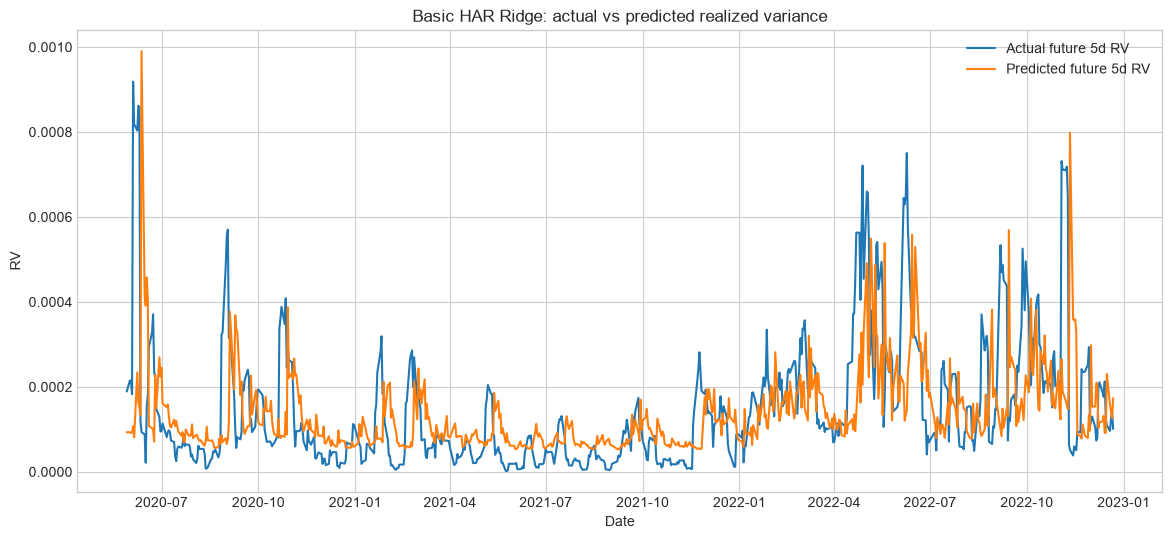

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label="Actual future 5d RV")
plt.plot(y_test.index, y_pred, label="Predicted future 5d RV")
plt.title("Basic HAR Ridge: actual vs predicted realized variance")
plt.xlabel("Date")
plt.ylabel("RV")
plt.legend()
plt.show()


  Regularization helps only marginally. Even for strong Ridge penalties the
out-of-sample $(R^2)$ remains below zero, so the poor performance is not just an
alpha-selection problem. The main issue is the raw RV scale: it is dominated by
large spikes and heavy-tailed shocks. This motivates the move to the log-HAR
model.

## 3. Jump-regime idea

Before moving to the log-scale model, we first try to address one visible weakness of the basic HAR model. The prediction is very smooth and follows the general level of volatility, but it reacts poorly to sudden volatility spikes. This suggests that the model may be missing information about short-term stress periods.

To capture this effect, we introduce a simple jump-regime indicator. The idea is to compare recent weekly realized volatility with the longer monthly realized volatility. If the weekly volatility is much larger than the monthly average, the market may be entering a short-term high-volatility regime.

We define the jump signal as

$$
JS_t = \frac{RV^{-5}_t}{RV^{-22}_t}.
$$

Then we define the jump regime indicator as

$$
JR_t = 1(JS_t > 2).
$$

Finally, we interact this regime indicator with the HAR variables. This allows the model to use different effective slopes during possible volatility-jump periods. If the jump-regime model improves the forecast, it would suggest that sudden changes in the volatility state contain useful predictive information.


In [10]:
df = close["SP500"].to_frame()

df["Ret_1d"] = np.log(df["SP500"] / df["SP500"].shift(1))
df["RV_1d"] = df["Ret_1d"] ** 2

df["RV_lag_1"] = df["RV_1d"].shift(1)
df["RV_mean_5"] = df["RV_1d"].shift(1).rolling(5).mean()
df["RV_mean_22"] = df["RV_1d"].shift(1).rolling(22).mean()

df["vol_jump_signal"] = df["RV_mean_5"] / (df["RV_mean_22"] + EPS)
df["jump_regime"] = (df["vol_jump_signal"] > 2).astype(int)

df["RV_lag_1_jump"] = df["RV_lag_1"] * df["jump_regime"]
df["RV_mean_5_jump"] = df["RV_mean_5"] * df["jump_regime"]
df["RV_mean_22_jump"] = df["RV_mean_22"] * df["jump_regime"]

df["RV_forward_5"] = sum(
    df["RV_1d"].shift(-i) for i in range(1, 6)
) / 5

df[["RV_mean_5", "RV_mean_22", "vol_jump_signal", "jump_regime"]].dropna().head()


,RV_mean_5,RV_mean_22,vol_jump_signal,jump_regime
Date,,,,
2010-02-05,0.000299,0.000143,2.086573,1
2010-02-08,0.000281,0.000143,1.962916,0
2010-02-09,0.000257,0.000147,1.749618,0
2010-02-10,0.000257,0.000154,1.673279,0
2010-02-11,0.000252,0.000154,1.642177,0


In [11]:
features = [
    "RV_lag_1",
    "RV_mean_5",
    "RV_mean_22",
    "vol_jump_signal",
    "jump_regime",
    "RV_lag_1_jump",
    "RV_mean_5_jump",
    "RV_mean_22_jump",
]
target = "RV_forward_5"

model_df = df[[target] + features].dropna()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=TRAIN_FRACTION,
    shuffle=False,
)

ridge_alphas = [0.0, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]

jump_ridge_predictions = {}
jump_ridge_results = []
coef_rows = []

for alpha in ridge_alphas:
    if alpha == 0.0:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("regression", LinearRegression()),
        ])
        model_name = "OLS jump-HAR"
    else:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("regression", Ridge(alpha=alpha)),
        ])
        model_name = f"Jump-HAR Ridge alpha={alpha}"

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    jump_ridge_predictions[model_name] = y_pred

    jump_ridge_results.append({
        "model": model_name,
        "alpha": alpha,
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
    })

    regression = model.named_steps["regression"]

    coef_row = {
        "model": model_name,
        "alpha": alpha,
        "intercept": regression.intercept_,
    }

    coef_row.update({
        feature: coef
        for feature, coef in zip(features, regression.coef_)
    })

    coef_rows.append(coef_row)

jump_ridge_results = pd.DataFrame(jump_ridge_results).sort_values("RMSE")
jump_coef_df = pd.DataFrame(coef_rows)

display(jump_ridge_results)
display(jump_coef_df)

,model,alpha,MSE,RMSE,R2
6,Jump-HAR Ridge alpha=100.0,100.0,2.766941e-08,0.000166,-0.184574
5,Jump-HAR Ridge alpha=50.0,50.0,2.847917e-08,0.000169,-0.219241
4,Jump-HAR Ridge alpha=10.0,10.0,3.207551e-08,0.000179,-0.373206
3,Jump-HAR Ridge alpha=5.0,5.0,3.377309e-08,0.000184,-0.445883
2,Jump-HAR Ridge alpha=1.0,1.0,3.604724e-08,0.000190,-0.543243
1,Jump-HAR Ridge alpha=0.1,0.1,3.675363e-08,0.000192,-0.573485
0,OLS jump-HAR,0.0,3.683815e-08,0.000192,-0.577103


,model,alpha,intercept,RV_lag_1,RV_mean_5,RV_mean_22,vol_jump_signal,jump_regime,RV_lag_1_jump,RV_mean_5_jump,RV_mean_22_jump
0,OLS jump-HAR,0.0,0.000121,-0.000004,0.000177,0.000021,0.000014,0.000006,0.000165,-0.000813,0.000739
1,Jump-HAR Ridge alpha=0.1,0.1,0.000121,-0.000004,0.000177,0.000022,0.000014,0.000006,0.000164,-0.000808,0.000735
2,Jump-HAR Ridge alpha=1.0,1.0,0.000121,-0.000002,0.000171,0.000024,0.000014,0.000006,0.000159,-0.000766,0.000700
3,Jump-HAR Ridge alpha=5.0,5.0,0.000121,0.000004,0.000152,0.000031,0.000013,0.000008,0.000141,-0.000621,0.000578
4,Jump-HAR Ridge alpha=10.0,10.0,0.000121,0.000009,0.000136,0.000037,0.000012,0.000010,0.000126,-0.000500,0.000476
5,Jump-HAR Ridge alpha=50.0,50.0,0.000121,0.000024,0.000092,0.000052,0.000011,0.000014,0.000083,-0.000180,0.000210
6,Jump-HAR Ridge alpha=100.0,100.0,0.000121,0.000030,0.000077,0.000056,0.000011,0.000015,0.000068,-0.000087,0.000135


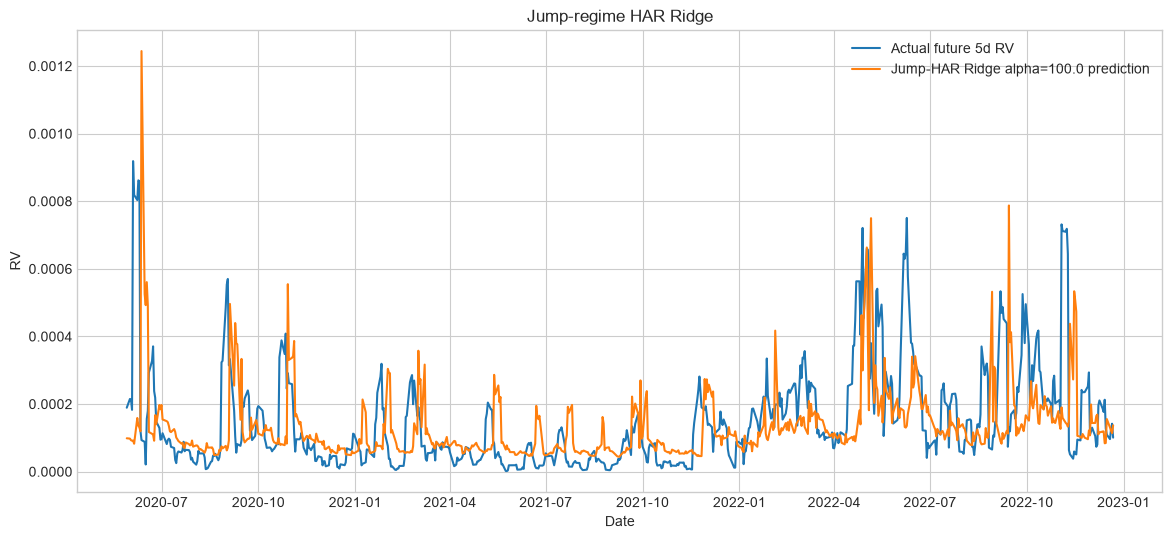

Best jump model: Jump-HAR Ridge alpha=100.0


In [12]:
best_jump_model_name = jump_ridge_results.iloc[0]["model"]
y_test_pred = jump_ridge_predictions[best_jump_model_name]

plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label="Actual future 5d RV")
plt.plot(y_test.index, y_test_pred, label=f"{best_jump_model_name} prediction")

plt.title("Jump-regime HAR Ridge")
plt.xlabel("Date")
plt.ylabel("RV")
plt.legend()
plt.show()

print("Best jump model:", best_jump_model_name)

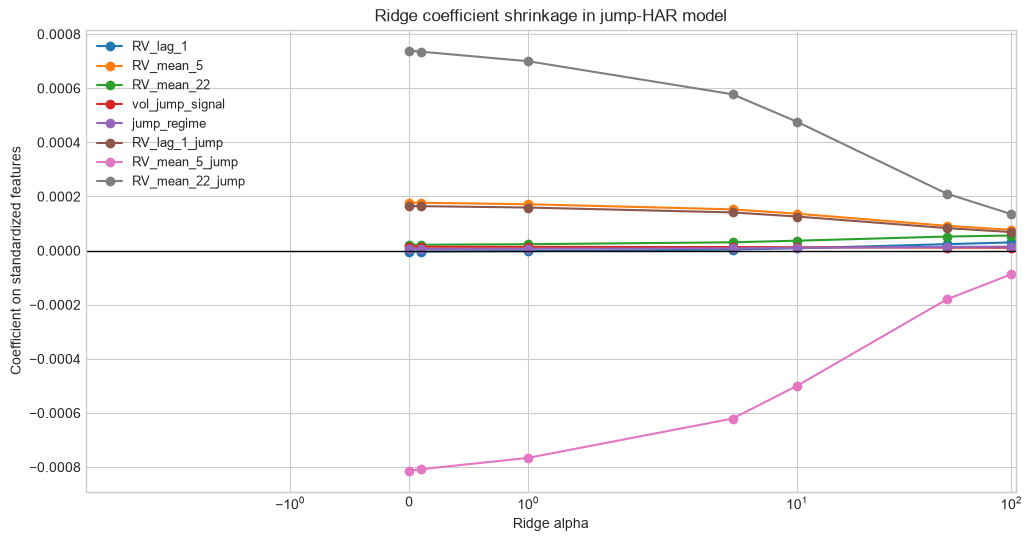

In [13]:
ax = jump_coef_df.set_index("alpha")[features].plot(
    figsize=(12, 6),
    marker="o",
)

ax.axhline(0, color="black", linewidth=1)
ax.set_xscale("symlog")
ax.set_title("Ridge coefficient shrinkage in jump-HAR model")
ax.set_xlabel("Ridge alpha")
ax.set_ylabel("Coefficient on standardized features")
ax.legend(loc="best", fontsize=9)


The jump-regime extension adds some value to the model, especially by allowing
the regression to react differently when short-term realized volatility is high
relative to the monthly average. The coefficient table also suggests that the
jump-related variables are not completely ignored by the model, so the signal
contains some information about changing volatility regimes.

However, the overall out-of-sample performance remains weak. Even after adding
jump-regime interactions and tuning the Ridge regularization strength, the model
does not solve the main problem: realized variance on the raw scale is dominated
by sharp spikes and heavy-tailed shocks.

This motivates the next step: instead of trying to forecast raw realized
variance directly, we move to a log-volatility specification, where the smoother
persistent component of volatility is easier to model.

## 4. Log-HAR model for S&P 500

The raw RV scale is very spiky and strictly positive. Now we move to the more
stable model used later in the presentation:

$$\log(RV^{mean}_t) = \beta_0 + \beta_1\log(RV^{-1}_t) + \beta_2\log(RV^{-5}_t) + \beta_3\log(RV^{-22}_t) + \epsilon_t.$$

Predictions are converted back to RV by exponentiating.


In [14]:
df = close["SP500"].to_frame()

df["Ret_1d"] = np.log(df["SP500"] / df["SP500"].shift(1))
df["RV_1d"] = df["Ret_1d"] ** 2

df["RV_lag_1"] = df["RV_1d"].shift(1)
df["RV_mean_5"] = df["RV_1d"].shift(1).rolling(5).mean()
df["RV_mean_22"] = df["RV_1d"].shift(1).rolling(22).mean()

df["RV_forward_5"] = sum(
    df["RV_1d"].shift(-i) for i in range(1, 6)
) / 5
# Quick remark those EPS are added just to improve numerical stability
df["log_RV_lag_1"] = np.log(df["RV_lag_1"] + EPS)
df["log_RV_mean_5"] = np.log(df["RV_mean_5"] + EPS)
df["log_RV_mean_22"] = np.log(df["RV_mean_22"] + EPS)
df["log_RV_forward_5"] = np.log(df["RV_forward_5"] + EPS)

features = ["log_RV_lag_1", "log_RV_mean_5", "log_RV_mean_22"]
target = "log_RV_forward_5"

model_df = df[features + [target, "RV_forward_5"]].dropna()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=TRAIN_FRACTION,
    shuffle=False,
)

model_df_test = model_df.loc[X_test.index]
rv_true = model_df_test["RV_forward_5"].values

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
model_df.head()


Train shape: (2595, 3)
Test shape: (649, 3)


,log_RV_lag_1,log_RV_mean_5,log_RV_mean_22,log_RV_forward_5,RV_forward_5
Date,,,,,
2010-02-05,-6.906928,-8.114848,-8.850371,-9.559970,0.000070
2010-02-08,-11.690971,-8.176355,-8.850786,-9.042281,0.000118
2010-02-09,-9.442778,-8.266645,-8.826043,-9.334693,0.000088
2010-02-10,-8.692417,-8.265312,-8.780097,-9.251968,0.000096
2010-02-11,-12.206966,-8.285046,-8.781069,-9.454777,0.000078


In [15]:
def qlike(y_true, y_pred, eps=1e-12):
    y_true = np.maximum(np.asarray(y_true), eps)
    y_pred = np.maximum(np.asarray(y_pred), eps)
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1)


def evaluate_point_model(name, y_true_log, y_pred_log, rv_true):
    rv_pred = np.exp(y_pred_log)
    return {
        "model": name,
        "RMSE_log": np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        "MAE_log": mean_absolute_error(y_true_log, y_pred_log),
        "R2_log": r2_score(y_true_log, y_pred_log),
        "RMSE_RV": np.sqrt(mean_squared_error(rv_true, rv_pred)),
        "MAE_RV": mean_absolute_error(rv_true, rv_pred),
        "R2_RV": r2_score(rv_true, rv_pred),
        "QLIKE": qlike(rv_true, rv_pred),
    }


In [16]:
ols = LinearRegression()
ols.fit(X_train, y_train)
y_pred_log_ols = ols.predict(X_test)
rv_pred_ols = np.exp(y_pred_log_ols)

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0)),
])
ridge_model.fit(X_train, y_train)
y_pred_log_ridge = ridge_model.predict(X_test)
rv_pred_ridge = np.exp(y_pred_log_ridge)

results = pd.DataFrame([
    evaluate_point_model("OLS HAR log(RV)", y_test.values, y_pred_log_ols, rv_true),
    evaluate_point_model("Ridge HAR log(RV)", y_test.values, y_pred_log_ridge, rv_true),
])

results


,model,RMSE_log,MAE_log,R2_log,RMSE_RV,MAE_RV,R2_RV,QLIKE
0,OLS HAR log(RV),0.973811,0.765658,0.239203,0.000153,0.00009,-0.002227,0.682492
1,Ridge HAR log(RV),0.973820,0.765673,0.239190,0.000153,0.00009,-0.002313,0.682515


In [17]:
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": ols.coef_,
})

print("OLS intercept:", ols.intercept_)
coef_df


OLS intercept: -2.938471479635191


,feature,coefficient
0,log_RV_lag_1,0.022832
1,log_RV_mean_5,0.320375
2,log_RV_mean_22,0.370478


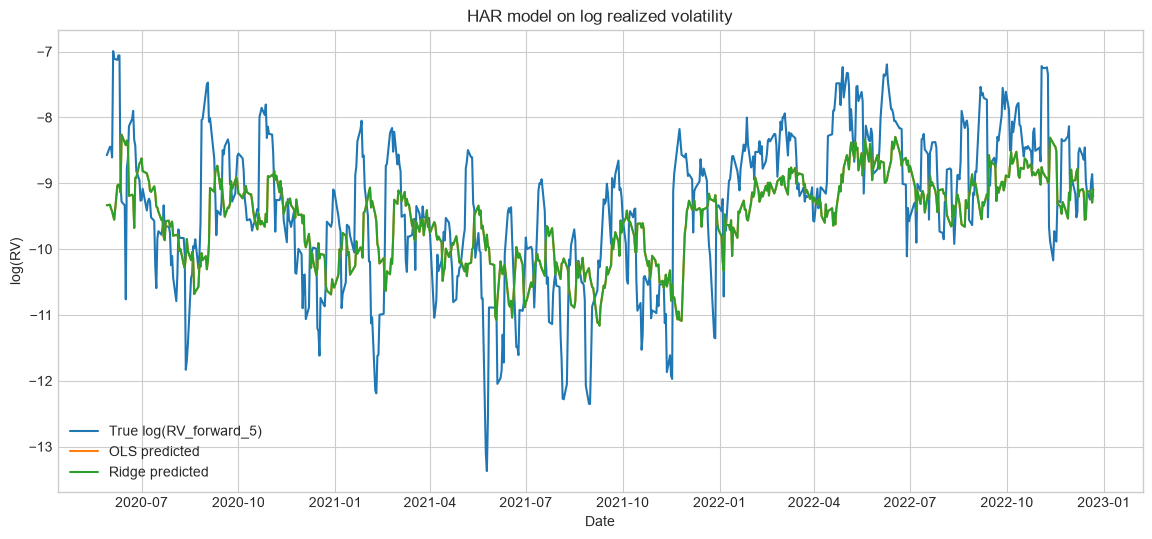

In [18]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label="True log(RV_forward_5)")
plt.plot(y_test.index, y_pred_log_ols, label="OLS predicted")
plt.plot(y_test.index, y_pred_log_ridge, label="Ridge predicted")
plt.title("HAR model on log realized volatility")
plt.xlabel("Date")
plt.ylabel("log(RV)")
plt.legend()
plt.show()


The log-HAR model is still too smooth to predict individual volatility spikes,
but actually we can argue that model captures the slower changes in the volatility regime. This suggests that the
linear HAR structure is not useless; it explains the smoother component of
log-volatility, while the sharp deviations remain as heavy-tailed shocks. This
naturally motivates a Bayesian model with predictive uncertainty, especially a
Student-t likelihood.

## 5. Bayesian HAR models

Now we use the same log-HAR design matrix, but estimate it Bayesianly.

Normal model:

$$y_t \sim N(\mu_t, \sigma).$$

Student-t model:

$$y_t \sim t_\nu(\mu_t, \sigma), \quad \nu = 2 + \operatorname{Exp}(1/10).$$

The Student-t likelihood is important because volatility residuals are usually
heavy-tailed.


In [93]:
def evaluate_bayesian_predictions(name, y_true_log, pred_samples_log, rv_true):
    pred_mean_log = pred_samples_log.mean(axis=0)

    lower_70_log = np.quantile(pred_samples_log, 0.15, axis=0)
    upper_40_log = np.quantile(pred_samples_log, 0.70, axis=0)
    upper_50_log = np.quantile(pred_samples_log, 0.75, axis=0)
    upper_60_log = np.quantile(pred_samples_log, 0.80, axis=0)
    upper_70_log = np.quantile(pred_samples_log, 0.85, axis=0)
    lower_80_log = np.quantile(pred_samples_log, 0.10, axis=0)
    upper_80_log = np.quantile(pred_samples_log, 0.90, axis=0)
    lower_95_log = np.quantile(pred_samples_log, 0.025, axis=0)
    upper_95_log = np.quantile(pred_samples_log, 0.975, axis=0)

    rv_pred_mean = np.exp(pred_mean_log)
    lower_70_rv = np.exp(lower_70_log)
    upper_40_rv = np.exp(upper_40_log)
    upper_50_rv = np.exp(upper_50_log)
    upper_60_rv = np.exp(upper_60_log)
    upper_70_rv = np.exp(upper_70_log)
    lower_80_rv = np.exp(lower_80_log)
    upper_80_rv = np.exp(upper_80_log)
    lower_95_rv = np.exp(lower_95_log)
    upper_95_rv = np.exp(upper_95_log)

    result = evaluate_point_model(name, y_true_log, pred_mean_log, rv_true)
    result.update({
        "coverage_70_log": np.mean((y_true_log >= lower_70_log) & (y_true_log <= upper_70_log)),
        "coverage_80_log": np.mean((y_true_log >= lower_80_log) & (y_true_log <= upper_80_log)),
        "coverage_95_log": np.mean((y_true_log >= lower_95_log) & (y_true_log <= upper_95_log)),
        "avg_width_70_log": np.mean(upper_70_log - lower_70_log),
        "avg_width_80_log": np.mean(upper_80_log - lower_80_log),
        "avg_width_95_log": np.mean(upper_95_log - lower_95_log),
        "coverage_70_RV": np.mean((rv_true >= lower_70_rv) & (rv_true <= upper_70_rv)),
        "coverage_80_RV": np.mean((rv_true >= lower_80_rv) & (rv_true <= upper_80_rv)),
        "coverage_95_RV": np.mean((rv_true >= lower_95_rv) & (rv_true <= upper_95_rv)),
        "avg_width_70_RV": np.mean(upper_70_rv - lower_70_rv),
        "avg_width_80_RV": np.mean(upper_80_rv - lower_80_rv),
        "avg_width_95_RV": np.mean(upper_95_rv - lower_95_rv),
    })

    intervals = {
        "pred_mean_log": pred_mean_log,
        "upper_40_log" : upper_40_log,
        "upper_50_log" : upper_50_log,
        "upper_60_log" : upper_60_log,
        "lower_70_log": lower_70_log,
        "upper_70_log": upper_70_log,
        "lower_80_log": lower_80_log,
        "upper_80_log": upper_80_log,
        "lower_95_log": lower_95_log,
        "upper_95_log": upper_95_log,
        "rv_pred_mean": rv_pred_mean,
        "lower_70_rv": lower_70_rv,
        "upper_40_rv": upper_40_rv,
        "upper_50_rv": upper_50_rv,
        "upper_60_rv": upper_60_rv,
        "upper_70_rv": upper_70_rv,
        "lower_80_rv": lower_80_rv,
        "upper_80_rv": upper_80_rv,
        "lower_95_rv": lower_95_rv,
        "upper_95_rv": upper_95_rv,
    }

    return result, intervals


In [94]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

coords_train = {
    "obs_id": np.arange(X_train_scaled.shape[0]),
    "feature": features,
}

with pm.Model(coords=coords_train) as normal_model:
    X_data = pm.Data("X_data", X_train_scaled, dims=("obs_id", "feature"))
    y_data = pm.Data("y_data", y_train_scaled, dims="obs_id")

    alpha = pm.Normal("alpha", mu=0.0, sigma=1.0)
    beta = pm.Normal("beta", mu=0.0, sigma=1.0, dims="feature")
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    mu = pm.Deterministic("mu", alpha + pm.math.dot(X_data, beta), dims="obs_id")

    y_obs = pm.Normal(
        "y_obs",
        mu=mu,
        sigma=sigma,
        observed=y_data,
        dims="obs_id",
    )

    normal_idata = pm.sample(
        draws=DRAWS,
        tune=TUNE,
        chains=CHAINS,
        target_accept=TARGET_ACCEPT,
        random_seed=RANDOM_SEED,
    )



                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   1500        0           0.497       15          263.99 draws/s       0:00:05    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   1500        0           0.590       7           350.33 draws/s       0:00:04    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   1500        0           0.504       3           607.42 draws/s       0:00:02    0:00:00

Sampling 3 chains for 500 tune and 1_000 draw iterations (1_500 + 3_000 draws total) took 11 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [95]:
normal_posterior_data = normal_idata.posterior
if hasattr(normal_posterior_data, "to_dataset"):
    normal_posterior_data = normal_posterior_data.to_dataset()

normal_posterior = normal_posterior_data.stack(sample=("chain", "draw"))

alpha_samples = normal_posterior["alpha"].values
beta_samples = normal_posterior["beta"].transpose("sample", "feature").values
sigma_samples = normal_posterior["sigma"].values

mu_test_scaled = alpha_samples[:, None] + beta_samples @ X_test_scaled.T
rng = np.random.default_rng(RANDOM_SEED)
normal_pred_scaled = rng.normal(mu_test_scaled, sigma_samples[:, None])

normal_pred_log = y_scaler.inverse_transform(
    normal_pred_scaled.reshape(-1, 1)
).reshape(normal_pred_scaled.shape)

normal_results, normal_intervals = evaluate_bayesian_predictions(
    "Bayesian HAR Normal",
    y_test.values,
    normal_pred_log,
    rv_true,
)


In [96]:
with pm.Model(coords=coords_train) as student_model:
    X_data = pm.Data("X_data", X_train_scaled, dims=("obs_id", "feature"))
    y_data = pm.Data("y_data", y_train_scaled, dims="obs_id")

    alpha = pm.Normal("alpha", mu=0.0, sigma=1.0)
    beta = pm.Normal("beta", mu=0.0, sigma=1.0, dims="feature")
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    nu_minus_two = pm.Exponential("nu_minus_two", lam=1 / 10)
    nu = pm.Deterministic("nu", nu_minus_two + 2)

    mu = pm.Deterministic("mu", alpha + pm.math.dot(X_data, beta), dims="obs_id")

    y_obs = pm.StudentT(
        "y_obs",
        nu=nu,
        mu=mu,
        sigma=sigma,
        observed=y_data,
        dims="obs_id",
    )

    student_idata = pm.sample(
        draws=DRAWS,
        tune=TUNE,
        chains=CHAINS,
        target_accept=TARGET_ACCEPT,
        random_seed=RANDOM_SEED,
    )


                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   1500        0           0.324       7           191.33 draws/s       0:00:07    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   1500        0           0.458       7           237.11 draws/s       0:00:06    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   1500        0           0.339       15          159.76 draws/s       0:00:09    0:00:00

Sampling 3 chains for 500 tune and 1_000 draw iterations (1_500 + 3_000 draws total) took 20 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [97]:
student_posterior_data = student_idata.posterior
if hasattr(student_posterior_data, "to_dataset"):
    student_posterior_data = student_posterior_data.to_dataset()

student_posterior = student_posterior_data.stack(sample=("chain", "draw"))

alpha_samples = student_posterior["alpha"].values
beta_samples = student_posterior["beta"].transpose("sample", "feature").values
sigma_samples = student_posterior["sigma"].values
nu_samples = student_posterior["nu"].values

mu_test_scaled = alpha_samples[:, None] + beta_samples @ X_test_scaled.T
student_pred_scaled = mu_test_scaled + sigma_samples[:, None] * rng.standard_t(
    df=nu_samples[:, None],
    size=mu_test_scaled.shape,
)

student_pred_log = y_scaler.inverse_transform(
    student_pred_scaled.reshape(-1, 1)
).reshape(student_pred_scaled.shape)

student_results, student_intervals = evaluate_bayesian_predictions(
    "Bayesian HAR Student-t",
    y_test.values,
    student_pred_log,
    rv_true,
)


In [86]:
all_results = pd.DataFrame(
    results.to_dict("records")
    + [normal_results, student_results]
)

all_results


,model,RMSE_log,MAE_log,R2_log,RMSE_RV,MAE_RV,R2_RV,QLIKE,coverage_70_log,coverage_80_log,coverage_95_log,avg_width_70_log,avg_width_80_log,avg_width_95_log,coverage_70_RV,coverage_80_RV,coverage_95_RV,avg_width_70_RV,avg_width_80_RV,avg_width_95_RV
0,OLS HAR log(RV),0.973811,0.765658,0.239203,0.000153,0.00009,-0.002227,0.682492,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ridge HAR log(RV),0.973820,0.765673,0.239190,0.000153,0.00009,-0.002313,0.682515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Bayesian HAR Normal,0.975154,0.766350,0.237103,0.000153,0.00009,-0.002740,0.684457,0.741140,0.822804,0.963020,2.155272,2.666562,4.074218,0.741140,0.822804,0.963020,0.000226,0.000308,0.000658
3,Bayesian HAR Student-t,0.971709,0.763159,0.242484,0.000152,0.00009,0.005212,0.675119,0.721109,0.805855,0.967643,2.035990,2.555942,4.147765,0.721109,0.805855,0.967643,0.000212,0.000292,0.000692


In [98]:
az.summary(normal_idata, var_names=["alpha", "beta", "sigma"])


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,-0.0001,0.0155,-0.025,0.025,3415,2316,1.00,0.00027,0.00019
beta[log_RV_lag_1],0.0473,0.0178,0.018,0.076,2811,2038,1.00,0.00034,0.00024
beta[log_RV_mean_5],0.321,0.0259,0.28,0.36,1986,2007,1.00,0.00058,0.00041
beta[log_RV_mean_22],0.287,0.0239,0.25,0.32,2281,1881,1.00,0.0005,0.00035
sigma,0.8058,0.0111,0.79,0.82,3379,2205,1.00,0.00019,0.00014


In [99]:
az.summary(student_idata, var_names=["alpha", "beta", "sigma", "nu"])


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.0048,0.0152,-0.02,0.029,3186,2204,1.00,0.00027,0.00018
beta[log_RV_lag_1],0.0462,0.0175,0.019,0.075,3163,2290,1.00,0.00031,0.00022
beta[log_RV_mean_5],0.318,0.0259,0.28,0.36,1722,1866,1.00,0.00062,0.00044
beta[log_RV_mean_22],0.297,0.0241,0.26,0.34,1941,1958,1.00,0.00055,0.00039
sigma,0.7222,0.0163,0.7,0.75,2508,2180,1.00,0.00033,0.00023
nu,10.37,1.99,7.8,14,2515,2385,1.00,0.04,0.039


## 6. Bayesian intervals and residuals

The point forecast is only one part of the Bayesian model. The intervals tell us
how uncertain the model is. For volatility warning systems this matters a lot:
sometimes the mean forecast is not above the danger threshold, but the upper
credible/predictive bound is.


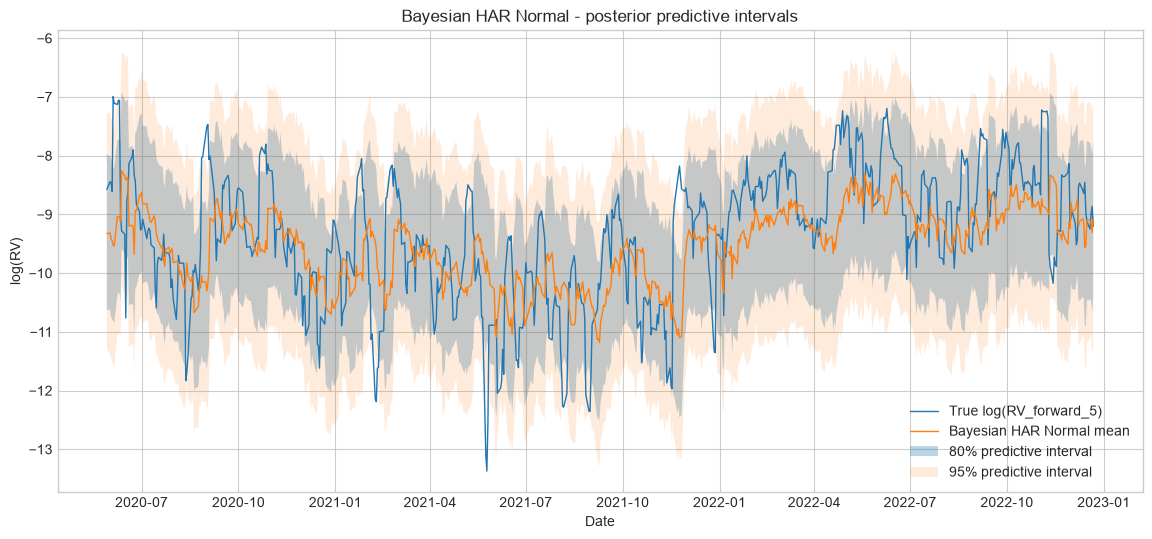

In [100]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label="True log(RV_forward_5)", linewidth=1)
plt.plot(y_test.index, normal_intervals["pred_mean_log"], label="Bayesian HAR Normal mean", linewidth=1)
plt.fill_between(
    y_test.index,
    normal_intervals["lower_80_log"],
    normal_intervals["upper_80_log"],
    alpha=0.30,
    label="80% predictive interval",
)
plt.fill_between(
    y_test.index,
    normal_intervals["lower_95_log"],
    normal_intervals["upper_95_log"],
    alpha=0.15,
    label="95% predictive interval",
)
plt.title("Bayesian HAR Normal - posterior predictive intervals")
plt.xlabel("Date")
plt.ylabel("log(RV)")
plt.legend()
plt.show()


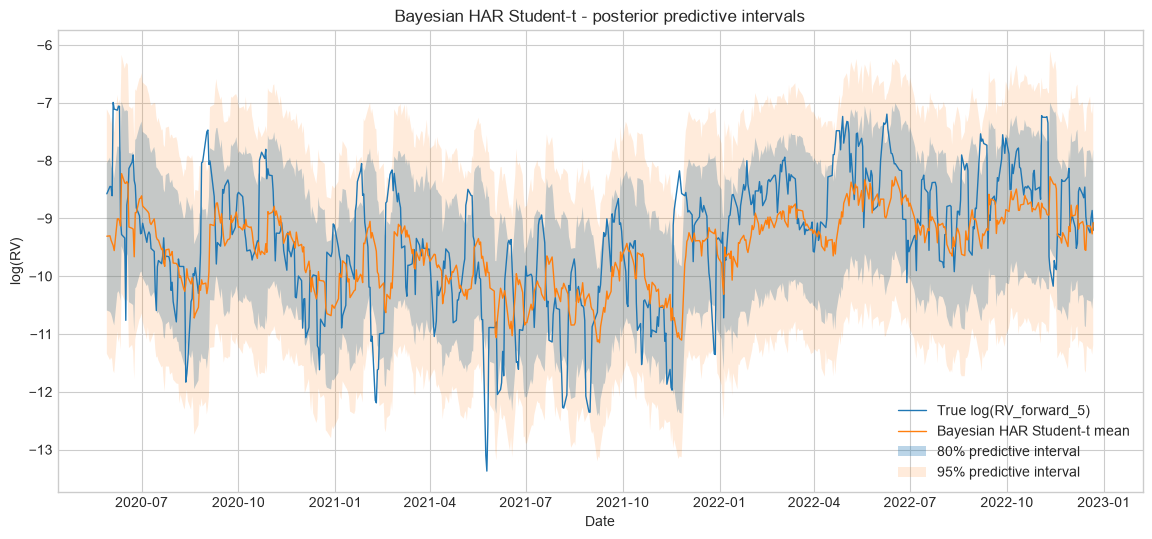

In [101]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label="True log(RV_forward_5)", linewidth=1)
plt.plot(y_test.index, student_intervals["pred_mean_log"], label="Bayesian HAR Student-t mean", linewidth=1)
plt.fill_between(
    y_test.index,
    student_intervals["lower_80_log"],
    student_intervals["upper_80_log"],
    alpha=0.30,
    label="80% predictive interval",
)
plt.fill_between(
    y_test.index,
    student_intervals["lower_95_log"],
    student_intervals["upper_95_log"],
    alpha=0.15,
    label="95% predictive interval",
)
plt.title("Bayesian HAR Student-t - posterior predictive intervals")
plt.xlabel("Date")
plt.ylabel("log(RV)")
plt.legend()
plt.show()


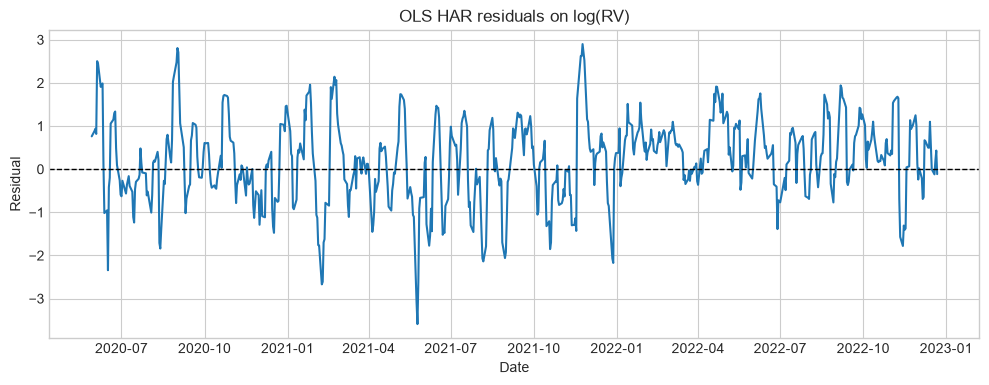

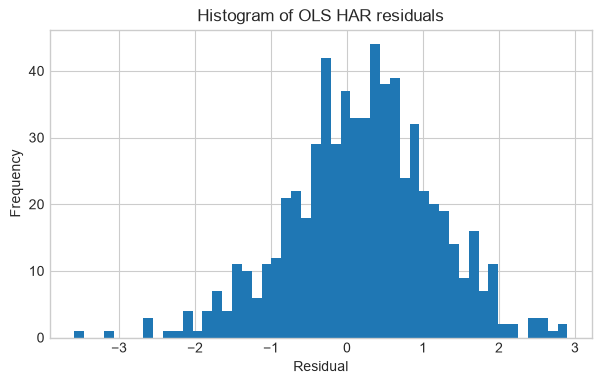

In [102]:
residuals_ols = y_test.values - y_pred_log_ols

plt.figure(figsize=(12, 4))
plt.plot(y_test.index, residuals_ols)
plt.axhline(0, linestyle="--", color="black", linewidth=1)
plt.title("OLS HAR residuals on log(RV)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(residuals_ols, bins=50)
plt.title("Histogram of OLS HAR residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()


## 7. Warning signals - more detailed version

The warning problem is not exactly the same as minimizing RMSE.

We define a high-volatility event as:

$$RV^{mean}_t > q_{0.8}(RV^{mean}),$$

so the top 20% of realized future-volatility observations are treated as events.

Then we compare several possible warning rules:

1. **OLS mean forecast**: warning if the classical mean forecast is above the threshold.
2. **Bayesian mean forecast**: warning if the Bayesian posterior predictive mean is above the threshold.
3. **Bayesian upper 40% bound**: warning if the upper 40% predictive bound is above the threshold.
4. **Bayesian upper 50% bound**: warning if the upper 50% predictive bound is above the threshold.
5. **Bayesian upper 60% bound**: warning if the upper 60% predictive bound is above the threshold.
6. **Bayesian upper 70% bound**: warning if the upper 70% predictive bound is above the threshold.
7. **Bayesian upper 80% bound**: warning if the upper 80% predictive bound is above the threshold.
8. **Bayesian upper 95% bound**: warning if the upper 95% predictive bound is above the threshold.

Interpretation:

- high precision means that warnings are usually correct,
- high recall means that most true high-volatility events are caught,
- upper-bound rules usually increase recall but create many more warnings.


In [103]:
signals_df = pd.DataFrame(index=y_test.index)

signals_df["rv_true"] = rv_true
signals_df["ols_pred"] = np.exp(y_pred_log_ols)
signals_df["ridge_pred"] = np.exp(y_pred_log_ridge)
signals_df["bayes_mean"] = student_intervals["rv_pred_mean"]
signals_df["bayes_upper_40"] = student_intervals["upper_40_rv"]
signals_df["bayes_upper_50"] = student_intervals["upper_50_rv"]
signals_df["bayes_upper_60"] = student_intervals["upper_60_rv"]
signals_df["bayes_upper_70"] = student_intervals["upper_70_rv"]
signals_df["bayes_upper_80"] = student_intervals["upper_80_rv"]
signals_df["bayes_upper_95"] = student_intervals["upper_95_rv"]

threshold = np.quantile(model_df["RV_forward_5"], 0.80)
print("Warning threshold:", threshold)

signals_df["high_vol_realized"] = (signals_df["rv_true"] > threshold).astype(int)
signals_df["warning_ols_mean"] = (signals_df["ols_pred"] > threshold).astype(int)
signals_df["warning_ridge_mean"] = (signals_df["ridge_pred"] > threshold).astype(int)
signals_df["warning_bayes_mean"] = (signals_df["bayes_mean"] > threshold).astype(int)
signals_df["warning_bayes_upper_40"] = (signals_df["bayes_upper_40"] > threshold).astype(int)
signals_df["warning_bayes_upper_50"] = (signals_df["bayes_upper_50"] > threshold).astype(int)
signals_df["warning_bayes_upper_60"] = (signals_df["bayes_upper_60"] > threshold).astype(int)
signals_df["warning_bayes_upper_70"] = (signals_df["bayes_upper_70"] > threshold).astype(int)
signals_df["warning_bayes_upper_80"] = (signals_df["bayes_upper_80"] > threshold).astype(int)
signals_df["warning_bayes_upper_95"] = (signals_df["bayes_upper_95"] > threshold).astype(int)

signals_df.head()


Warning threshold: 0.0001546407021158354


,rv_true,ols_pred,ridge_pred,bayes_mean,bayes_upper_40,bayes_upper_50,bayes_upper_60,bayes_upper_70,bayes_upper_80,bayes_upper_95,high_vol_realized,warning_ols_mean,warning_ridge_mean,warning_bayes_mean,warning_bayes_upper_40,warning_bayes_upper_50,warning_bayes_upper_60,warning_bayes_upper_70,warning_bayes_upper_80,warning_bayes_upper_95
Date,,,,,,,,,,,,,,,,,,,,
2020-05-29,0.000189,0.000088,0.000088,0.000091,0.000147,0.000173,0.000208,0.000255,0.000322,0.000816,1,0,0,0,0,1,1,1,1,1
2020-06-01,0.000215,0.000089,0.000089,0.000091,0.000153,0.000180,0.000213,0.000265,0.000353,0.000730,1,0,0,0,0,1,1,1,1,1
2020-06-02,0.000214,0.000084,0.000084,0.000085,0.000139,0.000163,0.000194,0.000238,0.000311,0.000632,1,0,0,0,0,1,1,1,1,1
2020-06-03,0.000183,0.000081,0.000081,0.000081,0.000133,0.000155,0.000184,0.000227,0.000291,0.000720,1,0,0,0,0,0,1,1,1,1
2020-06-04,0.000919,0.000075,0.000075,0.000077,0.000131,0.000153,0.000178,0.000218,0.000283,0.000621,1,0,0,0,0,0,1,1,1,1


In [104]:
def evaluate_warning(name, y_true, y_signal):
    return {
        "signal": name,
        "precision": precision_score(y_true, y_signal, zero_division=0),
        "recall": recall_score(y_true, y_signal, zero_division=0),
        "f1": f1_score(y_true, y_signal, zero_division=0),
        "n_warnings": int(y_signal.sum()),
        "n_high_vol": int(y_true.sum()),
    }

warning_results = pd.DataFrame([
    evaluate_warning(
        "OLS mean forecast",
        signals_df["high_vol_realized"],
        signals_df["warning_ols_mean"],
    ),
    evaluate_warning(
        "Ridge mean forecast",
        signals_df["high_vol_realized"],
        signals_df["warning_ridge_mean"],
    ),
    evaluate_warning(
        "Bayesian Student-t mean forecast",
        signals_df["high_vol_realized"],
        signals_df["warning_bayes_mean"],
    ),    
    evaluate_warning(
        "Bayesian Student-t upper 40%",
        signals_df["high_vol_realized"],
        signals_df["warning_bayes_upper_40"],
    ),
    evaluate_warning(
        "Bayesian Student-t upper 50%",
        signals_df["high_vol_realized"],
        signals_df["warning_bayes_upper_50"],
    ),
            evaluate_warning(
        "Bayesian Student-t upper 60%",
        signals_df["high_vol_realized"],
        signals_df["warning_bayes_upper_60"],
    ),
    evaluate_warning(
        "Bayesian Student-t upper 70%",
        signals_df["high_vol_realized"],
        signals_df["warning_bayes_upper_70"],
    ),
    evaluate_warning(
        "Bayesian Student-t upper 80%",
        signals_df["high_vol_realized"],
        signals_df["warning_bayes_upper_80"],
    ),
    evaluate_warning(
        "Bayesian Student-t upper 95%",
        signals_df["high_vol_realized"],
        signals_df["warning_bayes_upper_95"],
    ),
])

warning_results


,signal,precision,recall,f1,n_warnings,n_high_vol
0,OLS mean forecast,0.666667,0.207207,0.316151,69,222
1,Ridge mean forecast,0.666667,0.207207,0.316151,69,222
2,Bayesian Student-t mean forecast,0.657534,0.216216,0.325424,73,222
3,Bayesian Student-t upper 40%,0.537594,0.644144,0.586066,266,222
4,Bayesian Student-t upper 50%,0.504532,0.752252,0.603978,331,222
5,Bayesian Student-t upper 60%,0.479167,0.828829,0.607261,384,222
6,Bayesian Student-t upper 70%,0.443936,0.873874,0.588771,437,222
7,Bayesian Student-t upper 80%,0.411885,0.905405,0.566197,488,222
8,Bayesian Student-t upper 95%,0.343307,0.981982,0.508751,635,222


In [105]:
for column in [
    "warning_ols_mean",
    "warning_bayes_mean",
    "warning_bayes_upper_40",
    "warning_bayes_upper_50",
    "warning_bayes_upper_60",  
    "warning_bayes_upper_70",
    "warning_bayes_upper_80",
    "warning_bayes_upper_95",
]:
    print("\n", column)
    print(confusion_matrix(signals_df["high_vol_realized"], signals_df[column]))



 warning_ols_mean
[[404  23]
 [176  46]]

 warning_bayes_mean
[[402  25]
 [174  48]]

 warning_bayes_upper_40
[[304 123]
 [ 79 143]]

 warning_bayes_upper_50
[[263 164]
 [ 55 167]]

 warning_bayes_upper_60
[[227 200]
 [ 38 184]]

 warning_bayes_upper_70
[[184 243]
 [ 28 194]]

 warning_bayes_upper_80
[[140 287]
 [ 21 201]]

 warning_bayes_upper_95
[[ 10 417]
 [  4 218]]


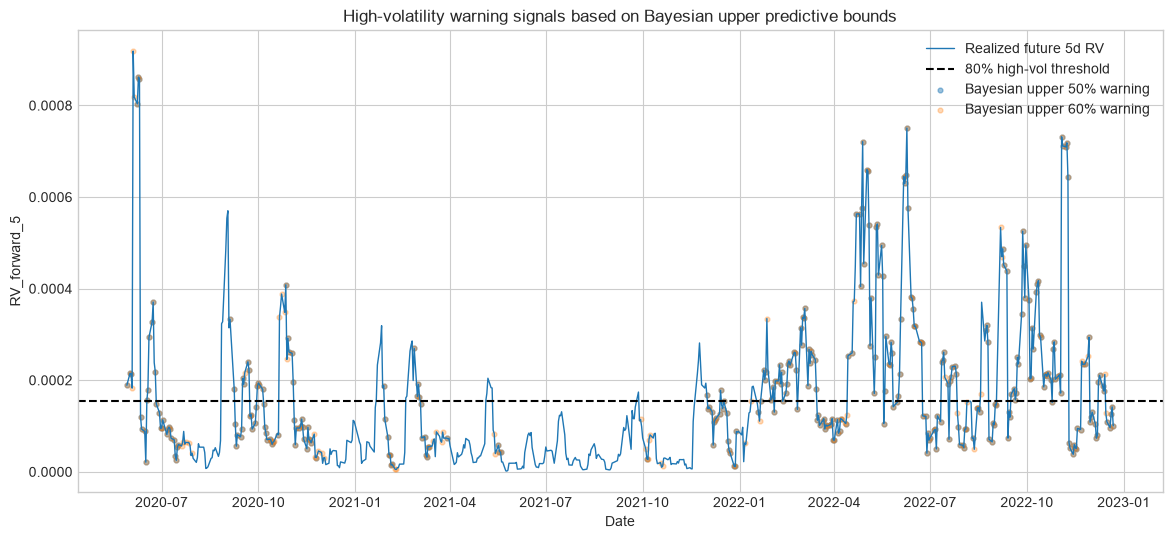

In [107]:
plt.figure(figsize=(14, 6))
plt.plot(signals_df.index, signals_df["rv_true"], label="Realized future 5d RV", linewidth=1)
plt.axhline(threshold, color="black", linestyle="--", label="80% high-vol threshold")
plt.scatter(
    signals_df.index[signals_df["warning_bayes_upper_50"] == 1],
    signals_df.loc[signals_df["warning_bayes_upper_50"] == 1, "rv_true"],
    s=12,
    alpha=0.45,
    label="Bayesian upper 50% warning",
)
plt.scatter(
    signals_df.index[signals_df["warning_bayes_upper_60"] == 1],
    signals_df.loc[signals_df["warning_bayes_upper_60"] == 1, "rv_true"],
    s=12,
    alpha=0.30,
    label="Bayesian upper 60% warning",
)
plt.title("High-volatility warning signals based on Bayesian upper predictive bounds")
plt.xlabel("Date")
plt.ylabel("RV_forward_5")
plt.legend()
plt.show()


## 8. Conclusions

The raw-RV models did not work well. We tried different Ridge penalties and then
added the jump-regime variables, but the improvement was small. This suggests
that the main problem is the raw target itself: it is noisy and heavily affected
by sudden spikes.

The results became more useful after taking logs. OLS and Ridge still missed the
largest moves, but they followed the general volatility level much better. In
other words, the HAR variables seem to explain the persistent part of
volatility, not the exact size of every shock.

This is also where the Bayesian models become useful. Their main advantage is
not a completely different mean forecast, but the full predictive distribution.
The Student-t version is a reasonable choice because it allows larger errors
than the Normal model.

For the warning system there is a clear trade-off. Mean-based warnings are more
selective, while warnings based on the upper predictive bound catch more
high-volatility periods but also produce more false alarms. Which rule is better
depends on whether we care more about missing a volatility event or about
sending too many warnings.
